# Section 1 - Environment set up

In [2]:
import pandas as pd
import numpy as np
import os
import spacy
import textstat
import shap
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle


DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

salminen   = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "salminen_clean.csv"))
hollenbeck = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "hollenbeck_clean.csv"))

print("Salminen shape:",   salminen.shape)
print("Hollenbeck shape:", hollenbeck.shape)

# Load the English language model from spaCy, disabling unnecessary components for efficiency
nlp = spacy.load('en_core_web_sm', disable=["tagger", "parser", "lemmatizer"])

# Define the feature columns to be used in the analysis
FEATURE_COLS = ['word_count', 'lexical_diversity', 'ne_density', 'readability']

d:\MSC BUSINESS ANALYTICS\Msc project\finalproject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Salminen shape: (40432, 6)
Hollenbeck shape: (381734, 10)


In [5]:
# Section 2 - Extract cost-proxy features

# Define a function to extract features from text
def extract(text, doc):
    words = text.split()
    wc = len(words)
    return [wc, len(set(words))/wc, len(doc.ents)/wc, textstat.flesch_reading_ease(text)]

# Extract features for Salminen and Hollenbeck datasets

# Extract features for Salminen dataset
texts_sal = salminen['text_'].tolist() # Convert the 'text_' column to a list for processing
df_sal = pd.DataFrame(
    [extract(t, doc) for t, doc in zip(texts_sal, nlp.pipe(texts_sal, batch_size=2000))],
    columns=FEATURE_COLS
) # Use spaCy's nlp.pipe for efficient batch processing of texts, applied to the full review so that entity counts and word counts share the same span

# Add the 'is_fake' column to the features DataFrame and save it to a CSV file
df_sal['is_fake'] = salminen['is_fake'].values
df_sal.to_csv(os.path.join(RESULTS_DIR, "pipeline2_features_salminen.csv"), index=False)
print("Salminen features shape:", df_sal.shape)

# Extract features for Hollenbeck dataset
texts_hol = hollenbeck['review_text'].tolist() # Convert the 'review_text' column to a list for processing
df_hol = pd.DataFrame(
    [extract(t, doc) for t, doc in zip(texts_hol, nlp.pipe(texts_hol, batch_size=2000))],
    columns=FEATURE_COLS
) # Use spaCy's nlp.pipe for efficient batch processing of texts, applied to the full review so that entity counts and word counts share the same span

# Add the 'is_fake' column to the features DataFrame and save it to a CSV file
df_hol['is_fake'] = hollenbeck['is_fake'].values
df_hol.to_csv(os.path.join(RESULTS_DIR, "pipeline2_features_hollenbeck.csv"), index=False)

# Pickle feature DataFrames to avoid rerunning spaCy extraction (+1 hour)
with open(os.path.join(RESULTS_DIR, "pipeline2_features.pkl"), "wb") as f:
    pickle.dump({'df_sal': df_sal, 'df_hol': df_hol}, f)

Salminen features shape: (40432, 5)


In [5]:
# Section 3 - Statistical comparison: AI-generated fakes vs human-incentivised fakes

# Load pre-extracted features from pickle to avoid rerunning spaCy extraction (+1 hour)
with open(os.path.join(RESULTS_DIR, 'pipeline2_features.pkl'), 'rb') as f:
    data = pickle.load(f)
df_sal = data['df_sal']
df_hol = data['df_hol']

# Get the fake reviews from both datasets
sal_fake = df_sal[df_sal['is_fake'] == 1]
hol_fake = df_hol[df_hol['is_fake'] == 1]

# Define a function to compute bootstrap confidence intervals for the difference in means
def bootstrap_ci(a, b, n_boot=10000):
    rng = np.random.default_rng(42)
    diffs = [rng.choice(a, len(a), replace=True).mean() -
             rng.choice(b, len(b), replace=True).mean()
             for _ in range(n_boot)]
    return np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

# Format p-values for reporting, using "< .001" for very small values
def fmt_p(p):
    return "< .001" if p < .001 else f"{p:.3f}".lstrip("0")

# Test skewness of feature distributions to justify use of non-parametric tests
skew_table = pd.DataFrame([
    {'Feature': col,
     'Salminen skew': f"{sal_fake[col].skew():.3f}",
     'Hollenbeck skew': f"{hol_fake[col].skew():.3f}"}
    for col in FEATURE_COLS
])
# Print skewness statistics in a formatted table
skew_out = skew_table.to_string(index=False, justify='center', col_space=18)
print("--- SKEWNESS STATISTICS ---".center(len(skew_out.split("\n")[0])))
print(skew_out)

# Perform statistical tests and compute bootstrap confidence intervals for each feature
rows = []
for col in FEATURE_COLS:
    a = sal_fake[col].values
    b = hol_fake[col].values
    low, high = bootstrap_ci(a, b)
    mw = stats.mannwhitneyu(a, b, alternative='two-sided')
    # Cliff's Delta derived from Mann-Whitney U statistic 
    d = (2 * mw.statistic) / (len(a) * len(b)) - 1
    rows.append({
        'Feature': col,
        'Salminen fake (mean)': f"{a.mean():.3f}",
        'Hollenbeck fake (mean)': f"{b.mean():.3f}",
        'p (MW)': fmt_p(mw.pvalue), # Get p-value from Mann-Whitney U test
        'p (Welch)': fmt_p(stats.ttest_ind(a, b, equal_var=False).pvalue), # Get p-value from Welch's t-test
        'Bootstrap 95% CI (Sal - Hol)': f"[{low:.3f}, {high:.3f}]",
        "Cliff's δ": f"{d:.3f}"
    })

# Assemble results into a table for reporting
results_table = pd.DataFrame(rows)
results_out = results_table.to_string(index=False, justify='center', col_space=16)
print("\n" + "--- STATISTICAL COMPARISON ---".center(len(results_out.split("\n")[0])))
print(results_out)


              --- SKEWNESS STATISTICS ---               
     Feature         Salminen skew     Hollenbeck skew  
       word_count         1.797              7.649      
lexical_diversity        -0.788             -0.248      
       ne_density         3.194              7.475      
      readability        -7.233             -1.587      

                                                        --- STATISTICAL COMPARISON ---                                                       
     Feature      Salminen fake (mean) Hollenbeck fake (mean)      p (MW)         p (Welch)     Bootstrap 95% CI (Sal - Hol)    Cliff's δ    
       word_count        61.288                60.364              < .001             .101             [-0.164, 2.017]            -0.145     
lexical_diversity         0.769                 0.834              < .001           < .001            [-0.067, -0.062]            -0.183     
       ne_density         0.023                 0.018              < .001           < .00

In [7]:
# Section 4 - Train LogReg + RF, extract SHAP values

# Define a function to run the machine learning pipeline and compute SHAP values for feature importance
def run_pipeline2(df_feat, dataset_name):
    X = df_feat[FEATURE_COLS].values
    y = df_feat['is_fake'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    ) # Split the dataset into training and testing sets, stratifying by the target variable to maintain class balance
    shap_out = {} # Dictionary to store SHAP values and corresponding test data for each model
    for name, model in [
        ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1))
    ]:
        model.fit(X_train, y_train)
        if name == 'LogisticRegression':
            sv = shap.LinearExplainer(model, X_train).shap_values(X_test)
        else:
            sv = shap.TreeExplainer(model).shap_values(X_test)
            if isinstance(sv, list): sv = sv[1] # If the SHAP values are returned as a list, select the values for the positive class
            elif sv.ndim == 3: sv = sv[:, :, 1] # If the SHAP values have three dimensions, select the values for the positive class
        shap_out[name] = (sv, X_test)
    return shap_out

sal_shap = run_pipeline2(df_sal, 'Salminen')
hol_shap = run_pipeline2(df_hol, 'Hollenbeck')

# Assemble mean absolute SHAP values into a table for reporting
rows = [
    {'Dataset': ds, 'Model': m,
     **{col: f"{val:.4f}" for col, val in zip(FEATURE_COLS, np.abs(shap_out[m][0]).mean(axis=0))}}
    for ds, shap_out in [('Salminen', sal_shap), ('Hollenbeck', hol_shap)]
    for m in shap_out
]
shap_table = pd.DataFrame(rows)
shap_out_str = shap_table.to_string(index=False, justify='center', col_space=18)
print("--- MEAN ABSOLUTE SHAP VALUES ---".center(len(shap_out_str.split("\n")[0])))
print(shap_out_str)

# Pickle SHAP results to avoid rerunning the ML pipeline (+3 hours)
with open(os.path.join(RESULTS_DIR, "pipeline2_shap_results.pkl"), "wb") as f:
    pickle.dump({'sal_shap': sal_shap, 'hol_shap': hol_shap}, f)

Background dataset has 32345 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32345 when initializing the masker.
Background dataset has 305387 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=305387 when initializing the masker.


                                        --- MEAN ABSOLUTE SHAP VALUES ---                                        
     Dataset             Model            word_count     lexical_diversity      ne_density        readability    
      Salminen     LogisticRegression       1.2419             1.5092             0.1763             0.5145      
      Salminen           RandomForest       0.1527             0.1879             0.0497             0.1237      
    Hollenbeck     LogisticRegression       0.0794             0.4832             0.3109             0.0547      
    Hollenbeck           RandomForest       0.1007             0.0579             0.0884             0.0820      


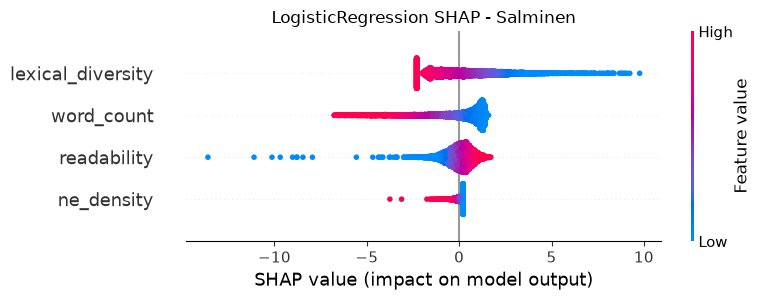

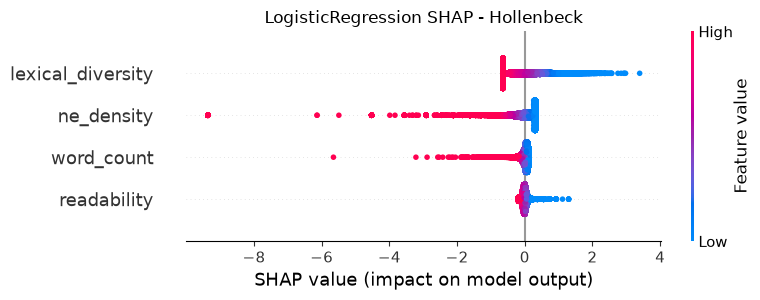

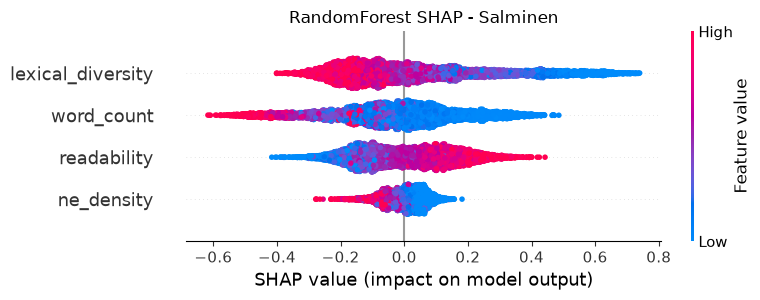

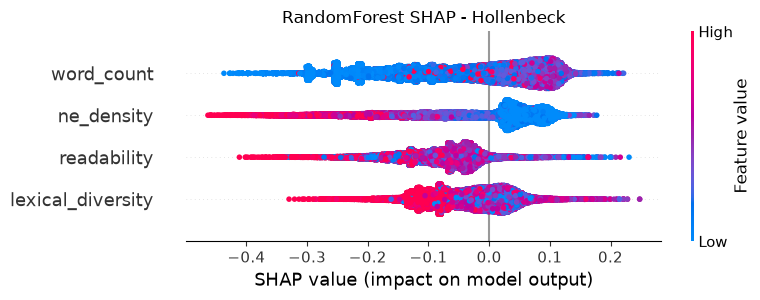

In [8]:
# Section 5 - Plot

# Define a function to plot SHAP summary plots for each model and dataset
def plot_shap(sv, X_test, model_name, dataset_name):
    plt.figure()
    shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS, show=False)
    plt.title(f"{model_name} SHAP - {dataset_name}")
    plt.tight_layout()
    model_short = {'LogisticRegression': 'logreg', 'RandomForest': 'rf'}
    plt.savefig(os.path.join(RESULTS_DIR, f"p2_shap_{model_short[model_name]}_{dataset_name.lower()}.png"))
    plt.show()

# Plot SHAP summary plots for each model and dataset
for name in ['LogisticRegression', 'RandomForest']:
    sv, X_test = sal_shap[name]
    plot_shap(sv, X_test, name, 'Salminen')
    sv, X_test = hol_shap[name]
    plot_shap(sv, X_test, name, 'Hollenbeck')